In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle-2.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection
!unzip -q brain-mri-images-for-brain-tumor-detection.zip -d dataset

!ls dataset

In [ ]:
!pip install -q torch torchvision timm scikit-learn matplotlib seaborn tqdm

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

In [ ]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB


In [ ]:
DATASET_PATH = '/content/dataset'
classes = ['yes', 'no']

## Dataset Exploration

In [ ]:
image_paths = []
labels = []
class_to_label = {'yes': 1, 'no': 0}

for class_name in classes:
    class_path = os.path.join(DATASET_PATH, class_name)
    if not os.path.exists(class_path):
        print(f"Warning: {class_path} does not exist!")
        continue

    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_name in image_files:
        img_path = os.path.join(class_path, img_name)
        image_paths.append(img_path)
        labels.append(class_to_label[class_name])

print(f"\nTotal Images: {len(image_paths)}")
print(f"Tumor (yes): {labels.count(1)} images ({labels.count(1)/len(labels)*100:.1f}%)")
print(f"No Tumor (no): {labels.count(0)} images ({labels.count(0)/len(labels)*100:.1f}%)")


Total Images: 253
Tumor (yes): 155 images (61.3%)
No Tumor (no): 98 images (38.7%)


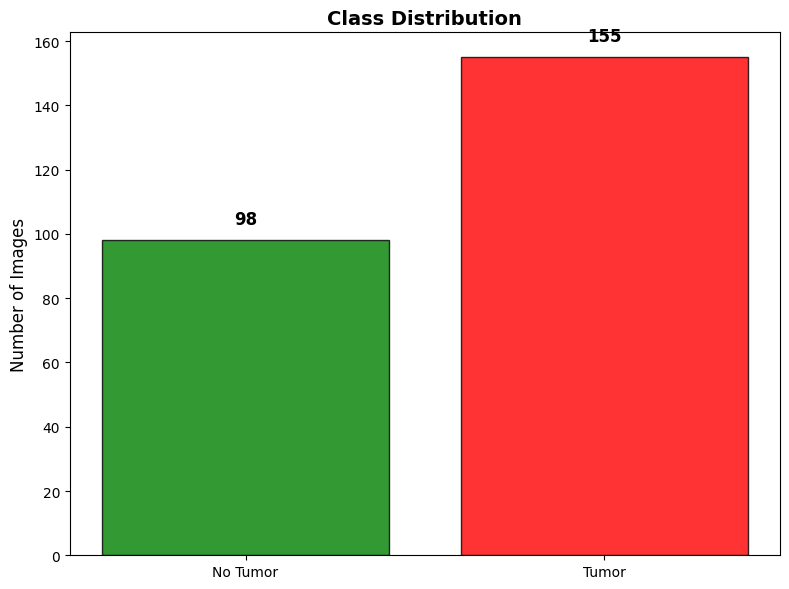

In [ ]:
# class distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
class_counts = [labels.count(0), labels.count(1)]
colors = ['green', 'red']
ax.bar(['No Tumor', 'Tumor'], class_counts, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Sample Images:


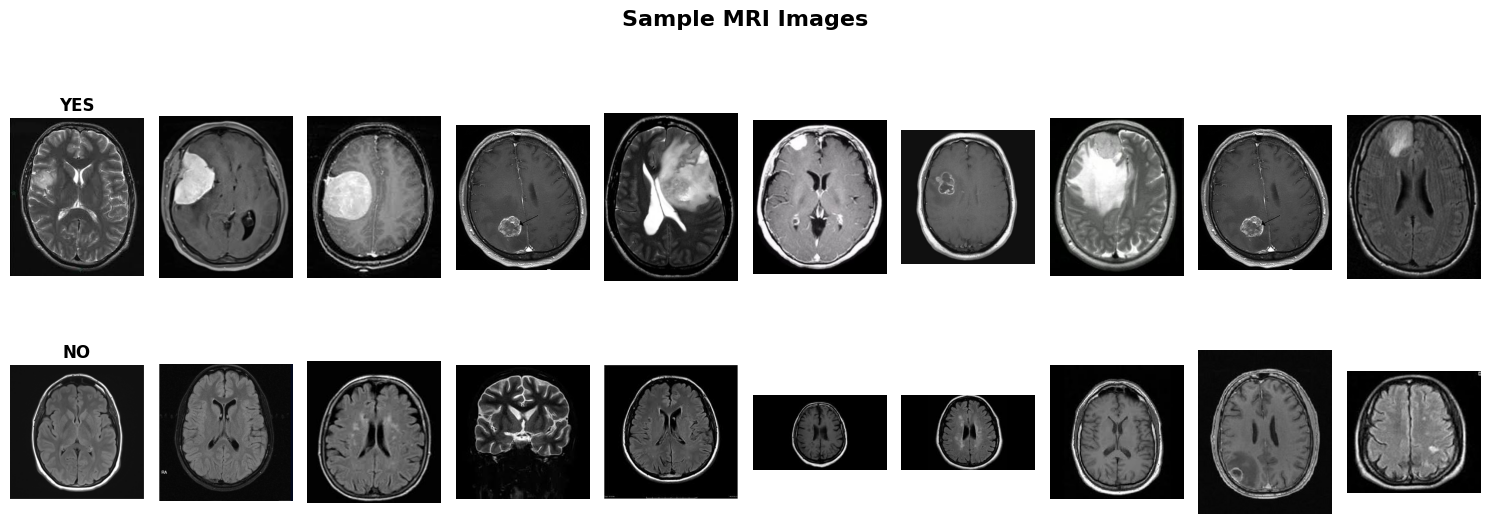

In [ ]:
print("\nSample Images:")
fig, axes = plt.subplots(2, 10, figsize=(15, 6))
fig.suptitle('Sample MRI Images', fontsize=16, fontweight='bold')

for i, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, class_name)
    sample_images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:10]

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f'{class_name.upper()}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Data Splitting

In [ ]:
# Split: 70% train, 15% validation, 15% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

splits = {
    'Train': (train_labels, len(train_paths)),
    'Validation': (val_labels, len(val_paths)),
    'Test': (test_labels, len(test_paths))
}

for split_name, (split_labels, split_size) in splits.items():
    yes_count = split_labels.count(1)
    no_count = split_labels.count(0)
    print(f"\n{split_name} Set:")
    print(f"  Total: {split_size} images ({split_size/len(image_paths)*100:.1f}%)")
    print(f"  Tumor: {yes_count} ({yes_count/split_size*100:.1f}%)")
    print(f"  No Tumor: {no_count} ({no_count/split_size*100:.1f}%)")


Train Set:
  Total: 177 images (70.0%)
  Tumor: 108 (61.0%)
  No Tumor: 69 (39.0%)

Validation Set:
  Total: 38 images (15.0%)
  Tumor: 24 (63.2%)
  No Tumor: 14 (36.8%)

Test Set:
  Total: 38 images (15.0%)
  Tumor: 23 (60.5%)
  No Tumor: 15 (39.5%)


## Custom Dataset Class

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## Data Augmentation and Preprocessing

In [ ]:
# ImageNet normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

#different aug solutions to prevent overfit/underfit
# aggresive aug for b0
train_transform_b0 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    transforms.Normalize(mean=mean, std=std)
])

# aug for b3
train_transform_b3 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12)),
    transforms.Normalize(mean=mean, std=std)
])

# val/test no augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Training augmentation: Random crop, flips, rotation, color jitter, erasing")
# Validation/Test: Resize only, no augmentation")

## Dataset and Data Loaders Creation

In [ ]:
# dataset for b0
train_dataset_b0 = BrainTumorDataset(train_paths, train_labels, train_transform_b0)
val_dataset = BrainTumorDataset(val_paths, val_labels, val_test_transform)
test_dataset = BrainTumorDataset(test_paths, test_labels, val_test_transform)

# for b3
train_dataset_b3 = BrainTumorDataset(train_paths, train_labels, train_transform_b3)

print(f"\nDataset sizes:")
print(f" - Train: {len(train_dataset_b0)}")
print(f" - Validation: {len(val_dataset)}")
print(f" - Test: {len(test_dataset)}")

BATCH_SIZE = 32
NUM_WORKERS = 2

# loaders for b0
train_loader_b0 = DataLoader(
    train_dataset_b0, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

# for b3
train_loader_b3 = DataLoader(
    train_dataset_b3, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

# val/test loaders
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\nDataLoader config:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Train batches (B0): {len(train_loader_b0)}")
print(f"  Train batches (B3): {len(train_loader_b3)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


Dataset sizes:
 - Train: 177
 - Validation: 38
 - Test: 38

DataLoader config:
  Batch size: 32
  Train batches (B0): 6
  Train batches (B3): 6
  Val batches: 2
  Test batches: 2


## Model Definitions

In [ ]:
def create_efficientnet(model_name='efficientnet_b0', pretrained=True, dropout=0.5):
    model = timm.create_model(model_name, pretrained=pretrained)
    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ftrs, 1)
    )
    return model

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Train Both Models

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        predictions = torch.sigmoid(outputs) > 0.5
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item()

        pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = torch.sigmoid(outputs) > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

            pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, model_name, train_loader, val_loader,
                num_epochs=50, patience=7, min_delta=0.01,
                lr=0.00005, weight_decay=5e-4):

    print(f"\nTraining {model_name}..")
    print(f"Parameters: LR={lr}, Weight Decay={weight_decay}, Patience={patience}")

    #loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-7
    )

    #tracking
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 70)

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Early stopping check
        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, f'best_{model_name}.pth')

            print(f"Best model saved (Val Loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

            if patience_counter >= patience:
                print(f"\nEarly stopping at Epoch {epoch+1}")
                print(f"Best model: Epoch {best_epoch}, Val Loss: {best_val_loss:.4f}")
                break

    # Load best model
    checkpoint = torch.load(f'best_{model_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    print(f"Training completed for {model_name}")
    print(f"Best Val Loss: {best_val_loss:.4f} (Epoch {best_epoch})")
    print(f"Best Val Acc: {checkpoint['val_acc']:.2f}%")

    return history, checkpoint

In [ ]:
def train_b3_progressive(train_loader, val_loader, device):
    ep = 8
    model = timm.create_model('efficientnet_b3', pretrained=True)

    # STAGE 1:only train the classifier
    print("\nStage 1: Training classifier only (5 epochs)...")
    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, 1)
    )
    model = model.to(device)

    optimizer = optim.Adam(model.classifier.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

    for epoch in range(ep):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}/{ep}: Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # STAGE 2: fine tune entire model
    print("\nStage 2: Fine-tuning entire model...")
    for param in model.parameters():
        param.requires_grad = True

    history, checkpoint = train_model(
        model, 'efficientnet_b3_progressive',
        train_loader, val_loader,
        num_epochs=40,
        patience=7,
        min_delta=0.01,
        lr=0.0001,
        weight_decay=7e-4
    )

    return model, history, checkpoint

## Train EfficientNet-B0

In [ ]:
model_b0 = create_efficientnet('efficientnet_b0', pretrained=True, dropout=0.6).to(device)
print(f"Model Parameters: {count_parameters(model_b0):,}")

history_b0, checkpoint_b0 = train_model(
    model_b0,
    'efficientnet_b0',
    train_loader_b0,
    val_loader,
    num_epochs=50,
    patience=7,
    min_delta=0.005,
    lr=0.00005,
    weight_decay=1e-3
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model Parameters: 4,008,829

Training efficientnet_b0..
Parameters: LR=5e-05, Weight Decay=0.001, Patience=7

Epoch 1/50
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.42it/s, loss=0.745, acc=31.6]



Epoch 1 Summary:
  Train Loss: 0.7083 | Train Acc: 48.59%
  Val Loss: 0.7311 | Val Acc: 31.58%
  LR: 0.000050
Best model saved (Val Loss: 0.7311)

Epoch 2/50
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.48it/s, loss=0.776, acc=47.4]


...


Epoch 39 Summary:
  Train Loss: 0.0803 | Train Acc: 98.87%
  Val Loss: 0.2975 | Val Acc: 92.11%
  LR: 0.000050
No improvement (5/7)

Epoch 40/50
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  4.99it/s, loss=0.449, acc=92.1]



Epoch 40 Summary:
  Train Loss: 0.0602 | Train Acc: 99.44%
  Val Loss: 0.3434 | Val Acc: 92.11%
  LR: 0.000050
No improvement (6/7)

Epoch 41/50
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  7.25it/s, loss=0.411, acc=92.1]



Epoch 41 Summary:
  Train Loss: 0.0662 | Train Acc: 98.87%
  Val Loss: 0.3230 | Val Acc: 92.11%
  LR: 0.000050
No improvement (7/7)

Early stopping at Epoch 41
Best model: Epoch 34, Val Loss: 0.2900
Training completed for efficientnet_b0
Best Val Loss: 0.2900 (Epoch 34)
Best Val Acc: 86.84%


## Train EfficientNet-B3

In [ ]:
model_b3, history_b3, checkpoint_b3 = train_b3_progressive(
    train_loader_b3,
    val_loader,
    device
)

print(f"Model Parameters: {count_parameters(model_b3):,}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Stage 1: Training classifier only (5 epochs)...


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.33it/s, loss=0.684, acc=57.9]


Epoch 1/8: Val Loss=0.6827, Val Acc=57.89%


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.92it/s, loss=0.653, acc=63.2]


...


Epoch 26 Summary:
  Train Loss: 0.0104 | Train Acc: 100.00%
  Val Loss: 0.3199 | Val Acc: 86.84%
  LR: 0.000100
No improvement (5/7)

Epoch 27/40
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.41it/s, loss=0.22, acc=86.8]



Epoch 27 Summary:
  Train Loss: 0.0086 | Train Acc: 100.00%
  Val Loss: 0.3358 | Val Acc: 86.84%
  LR: 0.000100
No improvement (6/7)

Epoch 28/40
----------------------------------------------------------------------


Validation: 100%|██████████| 2/2 [00:00<00:00,  5.85it/s, loss=0.243, acc=84.2]



Epoch 28 Summary:
  Train Loss: 0.0120 | Train Acc: 100.00%
  Val Loss: 0.3498 | Val Acc: 84.21%
  LR: 0.000100
No improvement (7/7)

Early stopping at Epoch 28
Best model: Epoch 21, Val Loss: 0.2922
Training completed for efficientnet_b3_progressive
Best Val Loss: 0.2922 (Epoch 21)
Best Val Acc: 89.47%
Model Parameters: 10,697,769


In [ ]:
print("Training Summary:\n")
print(f"\nEfficientNet-B0:")
print(f" - Best Val Loss: {checkpoint_b0['val_loss']:.4f}")
print(f" - Best Val Acc: {checkpoint_b0['val_acc']:.2f}%")
print(f" - Epochs Trained: {checkpoint_b0['epoch']}")
print(f" - Parameters: {count_parameters(model_b0):,}")

print(f"\nEfficientNet-B3:")
print(f" - Best Val Loss: {checkpoint_b3['val_loss']:.4f}")
print(f" - Best Val Acc: {checkpoint_b3['val_acc']:.2f}%")
print(f" - Epochs Trained: {checkpoint_b3['epoch']}")
print(f" - Parameters: {count_parameters(model_b3):,}")

Training Summary:


EfficientNet-B0:
 - Best Val Loss: 0.2900
 - Best Val Acc: 86.84%
 - Epochs Trained: 34
 - Parameters: 4,008,829

EfficientNet-B3:
 - Best Val Loss: 0.2922
 - Best Val Acc: 89.47%
 - Epochs Trained: 21
 - Parameters: 10,697,769


## Training Visualization

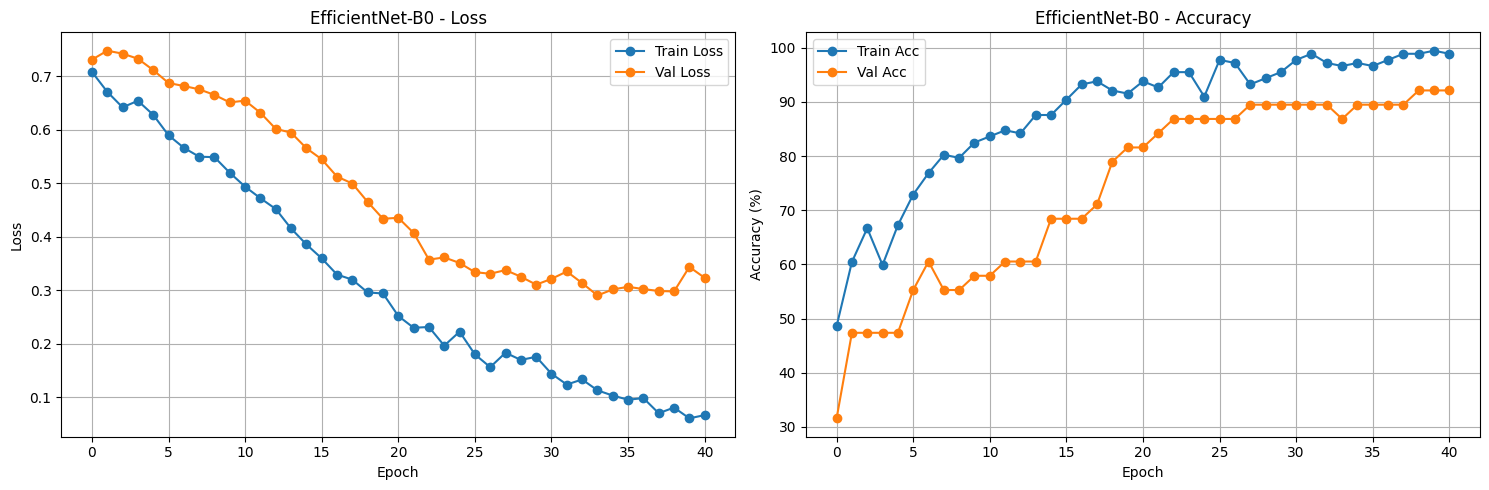

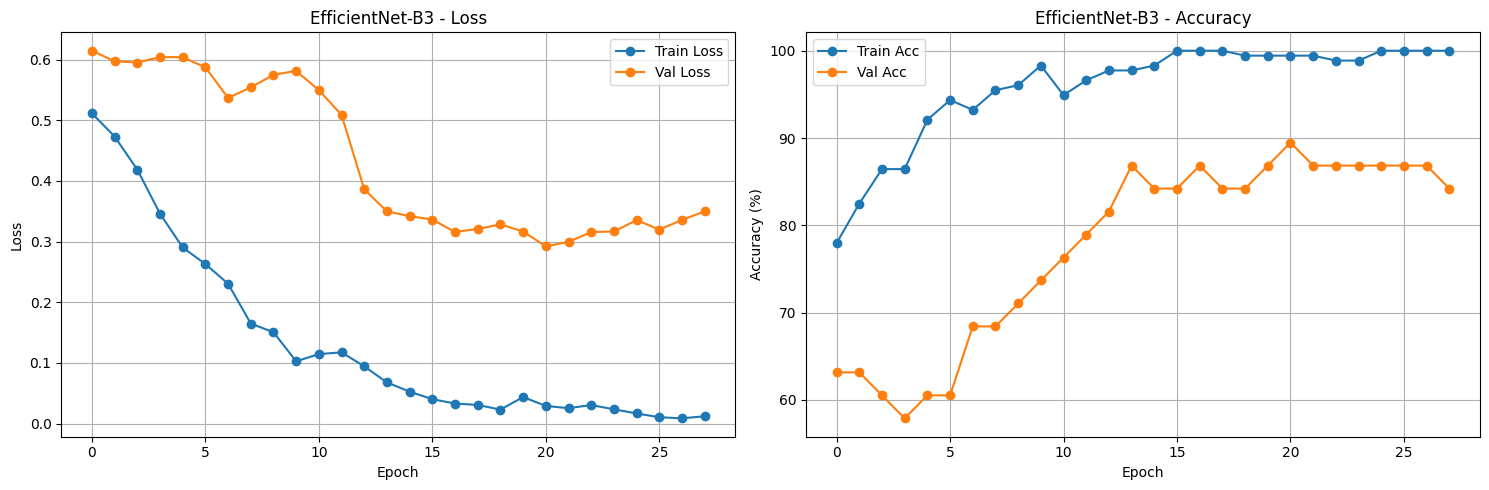

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name):
    """Plot training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot(history['train_acc'], label='Train Acc', marker='o')
    ax2.plot(history['val_acc'], label='Val Acc', marker='o')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} - Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot histories
plot_training_history(history_b0, 'EfficientNet-B0')
plot_training_history(history_b3, 'EfficientNet-B3')

## Test Set Evaluation


Step 1: Evaluating Models on Test Set

Evaluating EfficientNet-B0 on Test Set


Testing EfficientNet-B0: 100%|██████████| 2/2 [00:00<00:00,  6.58it/s]



EfficientNet-B0 Test Results:
Test Loss:      0.3800
Test Accuracy:  86.84%
Precision:      0.9500
Recall:         0.8261
F1-Score:       0.8837
Evaluating EfficientNet-B3 on Test Set


Testing EfficientNet-B3: 100%|██████████| 2/2 [00:00<00:00,  5.50it/s]



EfficientNet-B3 Test Results:
Test Loss:      0.5074
Test Accuracy:  76.32%
Precision:      0.9375
Recall:         0.6522
F1-Score:       0.7692

Step 2: Classification Reports

EfficientNet-B0 - Classification Report

              precision    recall  f1-score   support

    No Tumor     0.7778    0.9333    0.8485        15
       Tumor     0.9500    0.8261    0.8837        23

    accuracy                         0.8684        38
   macro avg     0.8639    0.8797    0.8661        38
weighted avg     0.8820    0.8684    0.8698        38

EfficientNet-B3 - Classification Report

              precision    recall  f1-score   support

    No Tumor     0.6364    0.9333    0.7568        15
       Tumor     0.9375    0.6522    0.7692        23

    accuracy                         0.7632        38
   macro avg     0.7869    0.7928    0.7630        38
weighted avg     0.8186    0.7632    0.7643        38


Step 3: Confusion Matrices



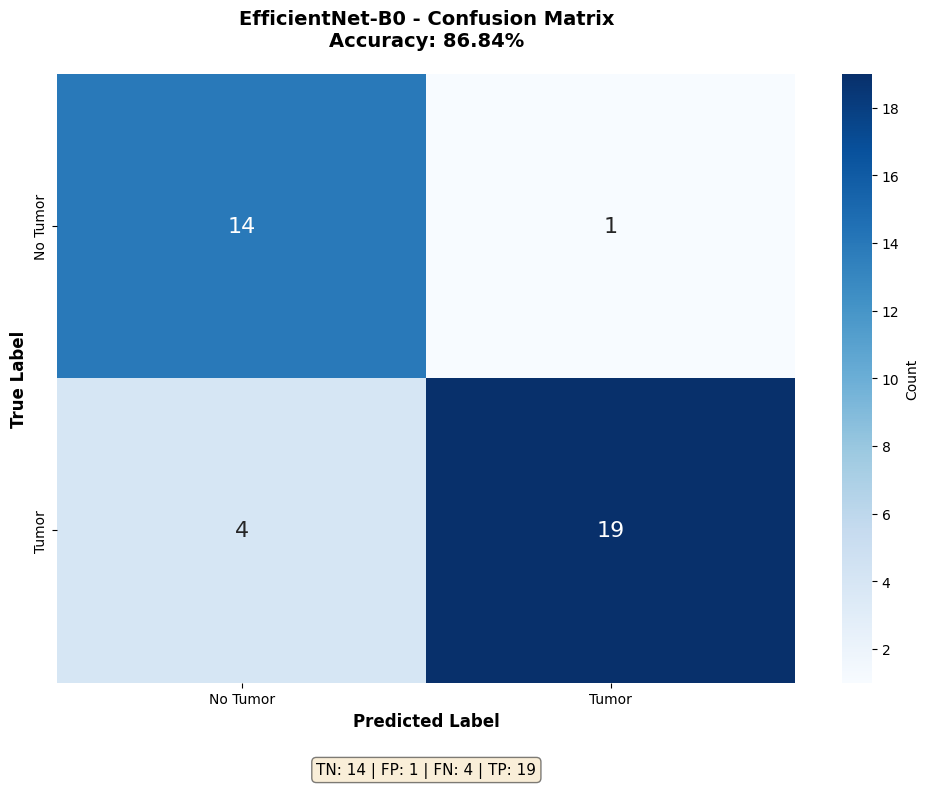


Confusion Matrix Details:
  True Negatives (TN):  14
  False Positives (FP): 1
  False Negatives (FN): 4
  True Positives (TP):  19

  Sensitivity (Recall): 0.8261
  Specificity:          0.9333


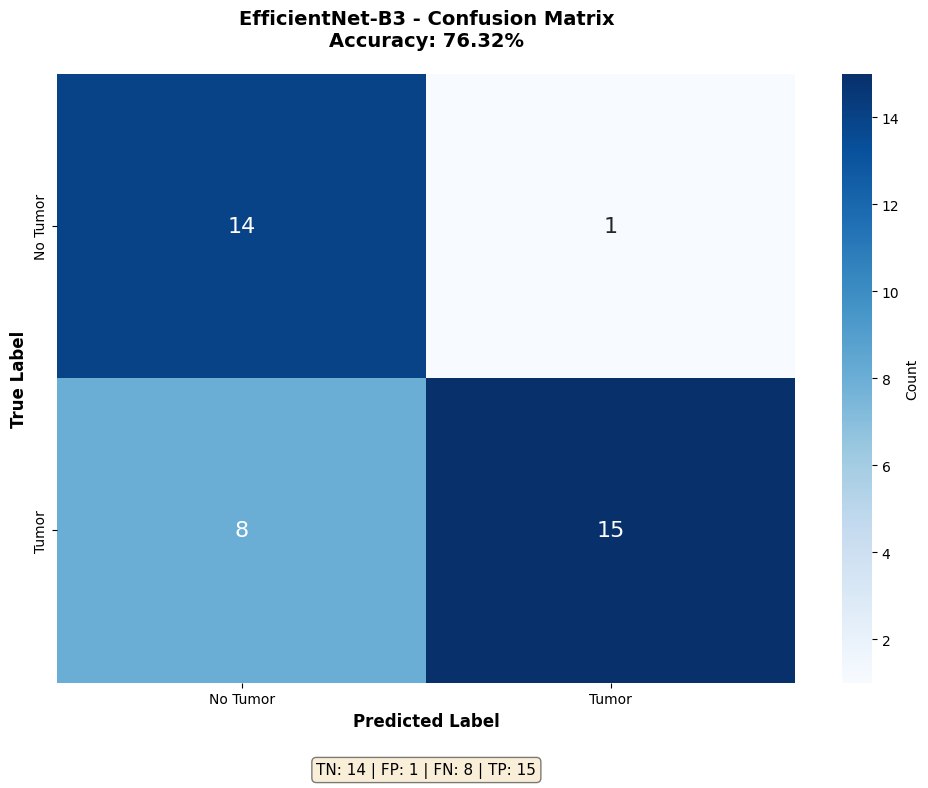


Confusion Matrix Details:
  True Negatives (TN):  14
  False Positives (FP): 1
  False Negatives (FN): 8
  True Positives (TP):  15

  Sensitivity (Recall): 0.6522
  Specificity:          0.9333

Step 4: ROC Curves



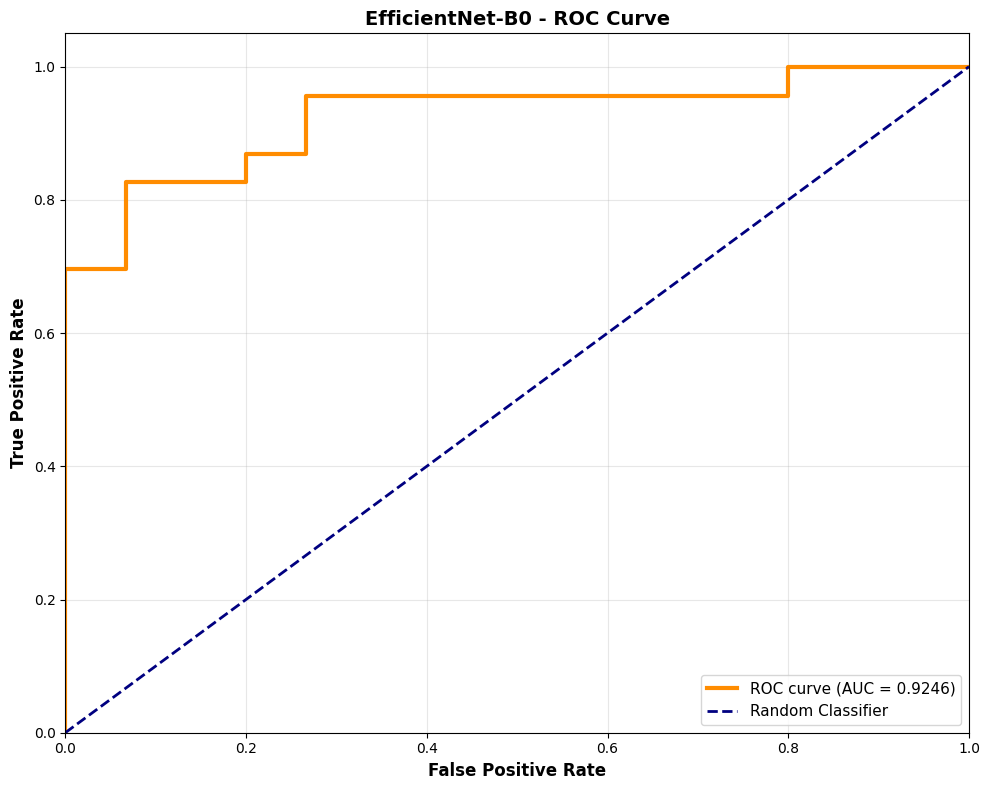


ROC AUC Score: 0.9246
Optimal Threshold: 0.5460
  TPR at optimal: 0.8261
  FPR at optimal: 0.0667


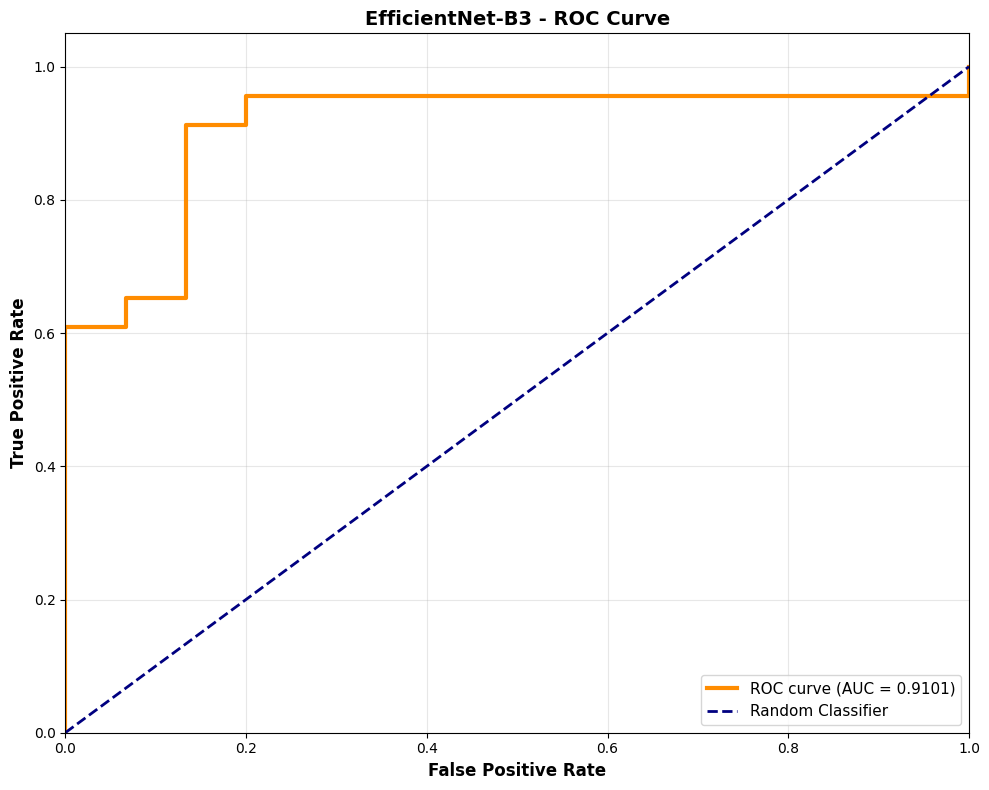


ROC AUC Score: 0.9101
Optimal Threshold: 0.0909
  TPR at optimal: 0.9130
  FPR at optimal: 0.1333

Step 5: Precision-Recall Curves



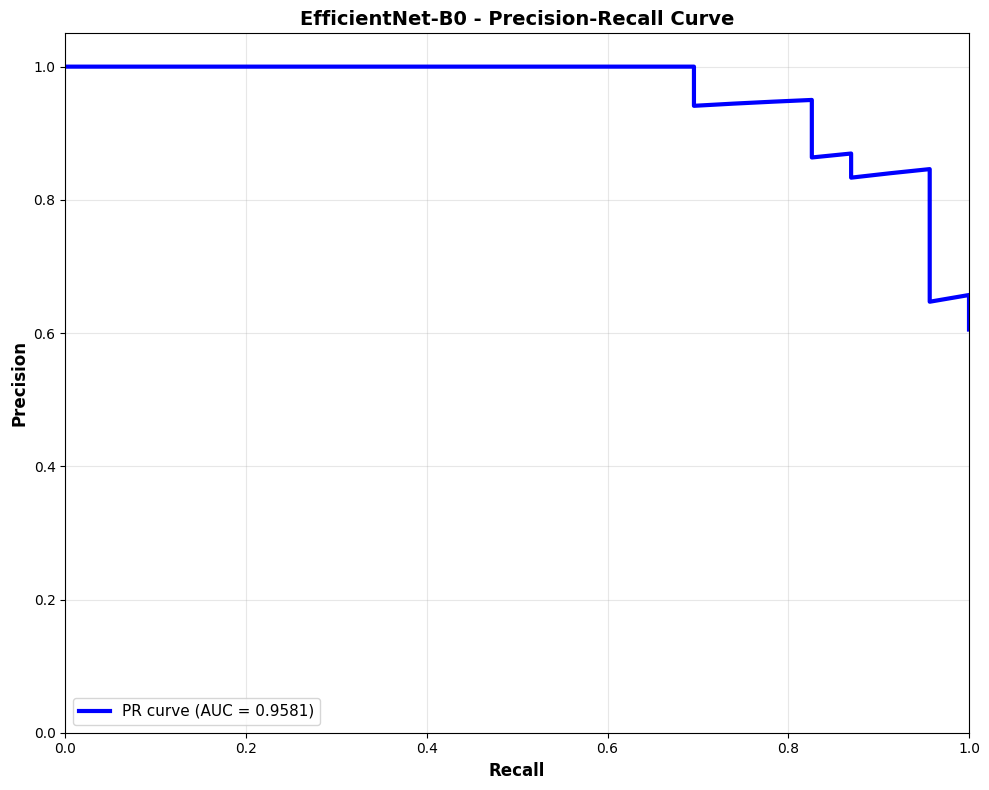


Precision-Recall AUC: 0.9581
Best F1 Threshold: 0.2048
  Best F1 Score: 0.8980
  Precision at best F1: 0.8462
  Recall at best F1: 0.9565


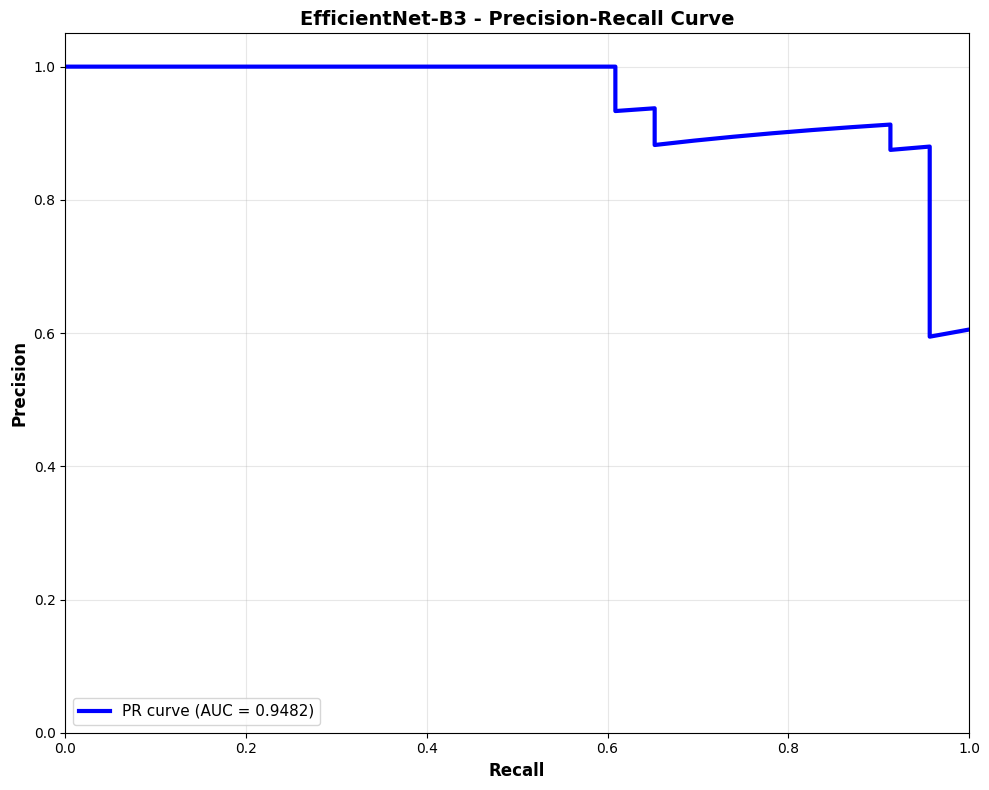


Precision-Recall AUC: 0.9482
Best F1 Threshold: 0.0413
  Best F1 Score: 0.9167
  Precision at best F1: 0.8800
  Recall at best F1: 0.9565

Step 6: Prediction Distributions



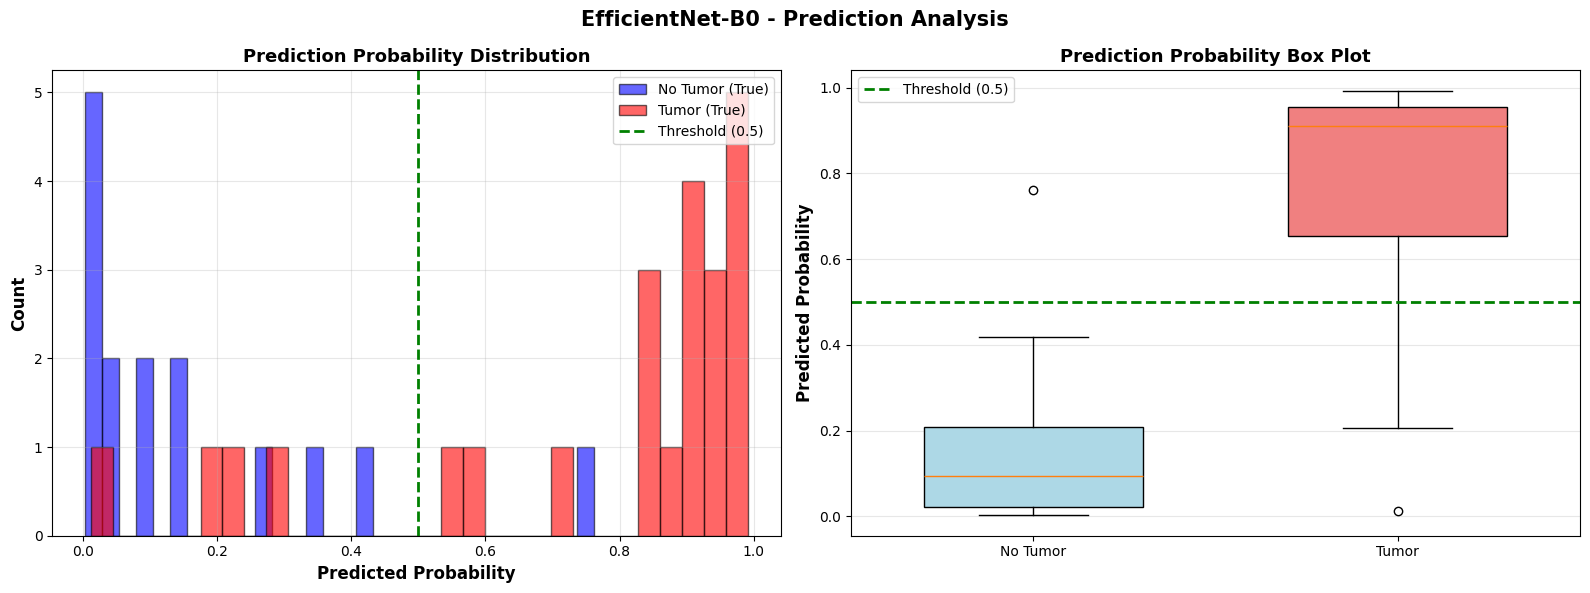

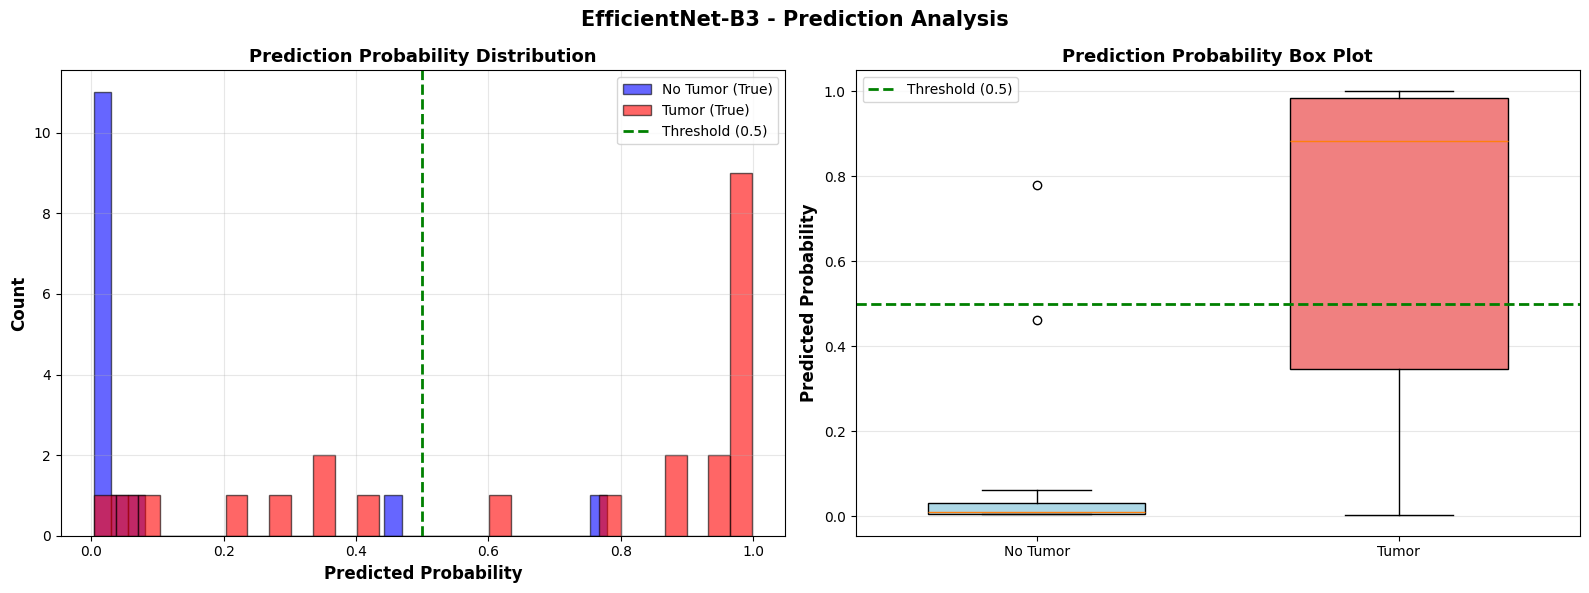


Step 7: Model Comparison



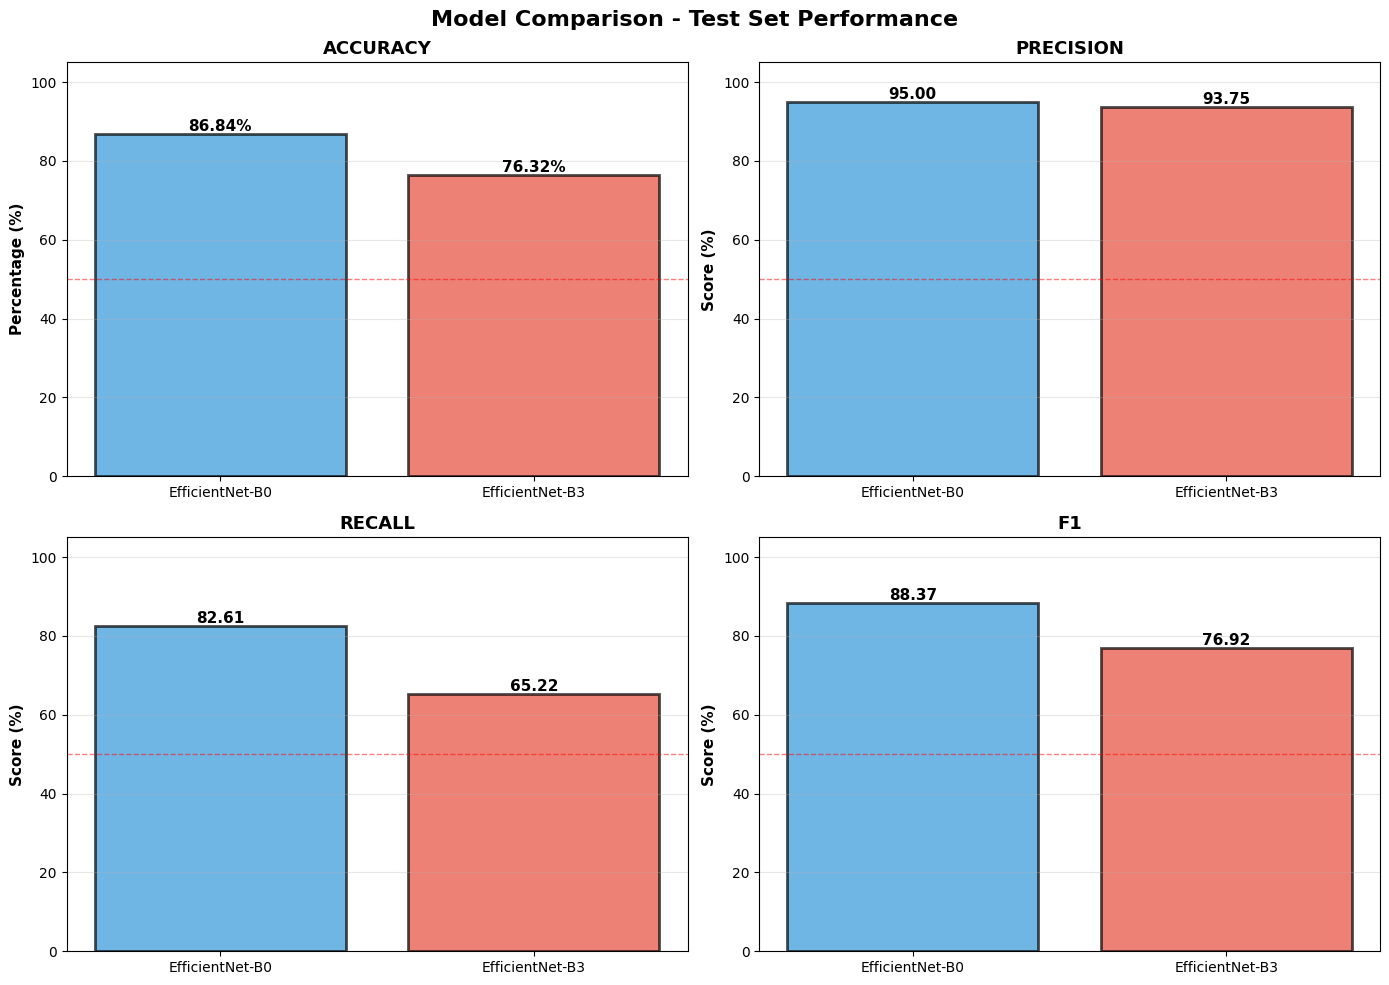

ACCURACY         86.84%       76.32%      -10.53%
PRECISION         0.9500        0.9375       -0.0125
RECALL            0.8261        0.6522       -0.1739
F1                0.8837        0.7692       -0.1145
LOSS              0.3800        0.5074       +0.1274

Best Model: B0

Evaluation Complete



In [ ]:
def evaluate_model_on_test(model, test_loader, device, model_name="Model"):
    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []
    test_loss = 0.0

    criterion = nn.BCEWithLogitsLoss()

    print(f"Evaluating {model_name} on Test Set")

    with torch.no_grad():
        pbar = tqdm(test_loader, desc=f'Testing {model_name}')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs).flatten()
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    test_loss = test_loss / len(test_loader)
    test_acc = 100 * (all_preds == all_labels).sum() / len(all_labels)

    # metrics
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    print(f"\n{model_name} Test Results:")
    print(f"Test Loss:      {test_loss:.4f}")
    print(f"Test Accuracy:  {test_acc:.2f}%")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1-Score:       {f1:.4f}")

    return {
        'loss': test_loss,
        'accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'probabilities': all_probs,
        'labels': all_labels
    }


def plot_confusion_matrix(results, model_name="Model", class_names=['No Tumor', 'Tumor']):
    cm = confusion_matrix(results['labels'], results['predictions'])

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, annot_kws={'size': 16})

    plt.title(f'{model_name} - Confusion Matrix\nAccuracy: {results["accuracy"]:.2f}%',
              fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')

    # Add counts in title
    tn, fp, fn, tp = cm.ravel()
    plt.text(0.5, -0.15,
             f'TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}',
             ha='center', transform=plt.gca().transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\nConfusion Matrix Details:")
    print(f"  True Negatives (TN):  {tn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  True Positives (TP):  {tp}")
    print(f"\n  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")


def plot_roc_curve(results, model_name="Model"):
    fpr, tpr, thresholds = roc_curve(results['labels'], results['probabilities'])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=3,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nROC AUC Score: {roc_auc:.4f}")

    # Find best threshold (Youden's index)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold: {optimal_threshold:.4f}")
    print(f"  TPR at optimal: {tpr[optimal_idx]:.4f}")
    print(f"  FPR at optimal: {fpr[optimal_idx]:.4f}")

    return roc_auc, optimal_threshold


def plot_precision_recall_curve(results, model_name="Model"):
    precision, recall, thresholds = precision_recall_curve(
        results['labels'], results['probabilities']
    )
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='blue', lw=3,
             label=f'PR curve (AUC = {pr_auc:.4f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=12, fontweight='bold')
    plt.ylabel('Precision', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nPrecision-Recall AUC: {pr_auc:.4f}")

    # Find best F1 score threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_f1_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else 0.5

    print(f"Best F1 Threshold: {best_threshold:.4f}")
    print(f"  Best F1 Score: {f1_scores[best_f1_idx]:.4f}")
    print(f"  Precision at best F1: {precision[best_f1_idx]:.4f}")
    print(f"  Recall at best F1: {recall[best_f1_idx]:.4f}")

    return pr_auc


def print_classification_report(results, model_name="Model",
                                class_names=['No Tumor', 'Tumor']):
    print(f"{model_name} - Classification Report\n")

    report = classification_report(
        results['labels'],
        results['predictions'],
        target_names=class_names,
        digits=4
    )
    print(report)


def plot_prediction_distribution(results, model_name="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    no_tumor_probs = results['probabilities'][results['labels'] == 0]
    tumor_probs = results['probabilities'][results['labels'] == 1]

    axes[0].hist(no_tumor_probs, bins=30, alpha=0.6, label='No Tumor (True)',
                 color='blue', edgecolor='black')
    axes[0].hist(tumor_probs, bins=30, alpha=0.6, label='Tumor (True)',
                 color='red', edgecolor='black')
    axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2,
                   label='Threshold (0.5)')
    axes[0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Box plot
    data_to_plot = [no_tumor_probs, tumor_probs]
    bp = axes[1].boxplot(data_to_plot, labels=['No Tumor', 'Tumor'],
                         patch_artist=True, widths=0.6)

    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[1].axhline(y=0.5, color='green', linestyle='--', linewidth=2,
                   label='Threshold (0.5)')
    axes[1].set_ylabel('Predicted Probability', fontsize=12, fontweight='bold')
    axes[1].set_title('Prediction Probability Box Plot', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis='y')

    plt.suptitle(f'{model_name} - Prediction Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_models(results_dict):
    models = list(results_dict.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metrics):
        values = [results_dict[model][metric] for model in models]

        if metric == 'accuracy':
            values_display = values
            ylabel = 'Percentage (%)'
        else:
            values_display = [v * 100 for v in values]
            ylabel = 'Score (%)'

        bars = axes[idx].bar(models, values_display,
                            color=['#3498db', '#e74c3c'],
                            alpha=0.7, edgecolor='black', linewidth=2)

        # Add value labels on bars
        for bar, val in zip(bars, values_display):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{val:.2f}%' if metric == 'accuracy' else f'{val:.2f}',
                          ha='center', va='bottom', fontweight='bold', fontsize=11)

        axes[idx].set_ylabel(ylabel, fontsize=11, fontweight='bold')
        axes[idx].set_title(metric.upper(), fontsize=13, fontweight='bold')
        axes[idx].set_ylim([0, 105 if metric == 'accuracy' else 105])
        axes[idx].grid(alpha=0.3, axis='y')

        # Add baseline
        if metric == 'accuracy':
            axes[idx].axhline(y=50, color='red', linestyle='--',
                            linewidth=1, alpha=0.5, label='Random (50%)')
        else:
            axes[idx].axhline(y=50, color='red', linestyle='--',
                            linewidth=1, alpha=0.5)

    plt.suptitle('Model Comparison - Test Set Performance',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


    for metric in ['accuracy', 'precision', 'recall', 'f1', 'loss']:
        if metric == 'accuracy':
            b0_val = results_dict[models[0]][metric]
            b3_val = results_dict[models[1]][metric]
            diff = b3_val - b0_val
            print(f"{metric.upper():<15} {b0_val:>6.2f}%      {b3_val:>6.2f}%      {diff:>+6.2f}%")
        else:
            b0_val = results_dict[models[0]][metric]
            b3_val = results_dict[models[1]][metric]
            if metric == 'loss':
                diff = b3_val - b0_val
                print(f"{metric.upper():<15} {b0_val:>8.4f}      {b3_val:>8.4f}      {diff:>+8.4f}")
            else:
                diff = b3_val - b0_val
                print(f"{metric.upper():<15} {b0_val:>8.4f}      {b3_val:>8.4f}      {diff:>+8.4f}")



#eval pipeline
def full_evaluation(model_b0, model_b3, test_loader, device):


    # 1. Evaluate both models
    print("\nStep 1: Evaluating Models on Test Set\n")
    results_b0 = evaluate_model_on_test(model_b0, test_loader, device, "EfficientNet-B0")
    results_b3 = evaluate_model_on_test(model_b3, test_loader, device, "EfficientNet-B3")

    print("\nStep 2: Classification Reports\n")
    print_classification_report(results_b0, "EfficientNet-B0")
    print_classification_report(results_b3, "EfficientNet-B3")

    print("\nStep 3: Confusion Matrices\n")
    plot_confusion_matrix(results_b0, "EfficientNet-B0")
    plot_confusion_matrix(results_b3, "EfficientNet-B3")

    # 4. ROC Curves
    print("\nStep 4: ROC Curves\n")
    roc_auc_b0, thresh_b0 = plot_roc_curve(results_b0, "EfficientNet-B0")
    roc_auc_b3, thresh_b3 = plot_roc_curve(results_b3, "EfficientNet-B3")

    # 5. Precision-Recall Curves
    print("\nStep 5: Precision-Recall Curves\n")
    pr_auc_b0 = plot_precision_recall_curve(results_b0, "EfficientNet-B0")
    pr_auc_b3 = plot_precision_recall_curve(results_b3, "EfficientNet-B3")

    # 6. Prediction Distributions
    print("\nStep 6: Prediction Distributions\n")
    plot_prediction_distribution(results_b0, "EfficientNet-B0")
    plot_prediction_distribution(results_b3, "EfficientNet-B3")

    # 7. Model Comparison
    print("\nStep 7: Model Comparison\n")
    results_dict = {
        'EfficientNet-B0': results_b0,
        'EfficientNet-B3': results_b3
    }
    compare_models(results_dict)


    winner = "B0" if results_b0['accuracy'] > results_b3['accuracy'] else \
             "B3" if results_b3['accuracy'] > results_b0['accuracy'] else "TIE"

    print(f"\nBest Model: {winner}")
    print(f"\nEvaluation Complete\n")

    return results_b0, results_b3

results_b0, results_b3 = full_evaluation(model_b0, model_b3, test_loader, device)
